# BirdCLEF 2026: Embeddings Comparison EDA

This notebook compares the pre-extracted embeddings from **BirdNET (v2.4)** and **Perch (v1)**. 
We have downloaded these from GCS to speed up our local experimentation.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

# Paths
PROCESSED_DIR = "../data/processed"
RAW_DIR = "../data/raw"

birdnet_path = os.path.join(PROCESSED_DIR, "birdnet_embeddings.npz")
perch_v1_path = os.path.join(PROCESSED_DIR, "perch_v1_embeddings.npz")
metadata_v1_path = os.path.join(PROCESSED_DIR, "train_with_perch_v1.csv")
raw_metadata_path = os.path.join(RAW_DIR, "train.csv")

## 1. Load Data

In [2]:
# Load Perch V1
perch_data = np.load(perch_v1_path)
perch_embeddings = perch_data['embeddings']
perch_indices = perch_data['indices']
train_perch_v1 = pd.read_csv(metadata_v1_path)

# Load BirdNET
birdnet_data = np.load(birdnet_path)
birdnet_embeddings = birdnet_data['embeddings']
birdnet_indices = birdnet_data['indices']

# Load raw metadata for full context
train_df = pd.read_csv(raw_metadata_path)

print(f"Perch V1: {perch_embeddings.shape} embeddings")
print(f"BirdNET: {birdnet_embeddings.shape} embeddings")

Perch V1: (35549, 1280) embeddings
BirdNET: (35549, 6522) embeddings


## 2. Compare Distributions

Perch usually produces normalized embeddings, while BirdNET (if extracted as logits) might have a different scale.

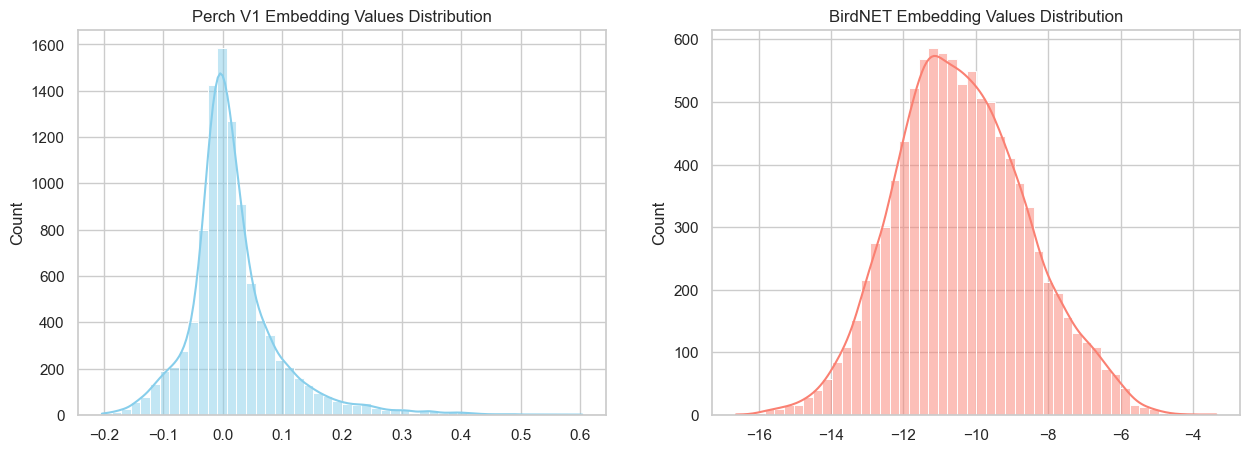

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(perch_embeddings.flatten()[:10000], bins=50, kde=True, ax=ax[0], color='skyblue')
ax[0].set_title("Perch V1 Embedding Values Distribution")

sns.histplot(birdnet_embeddings.flatten()[:10000], bins=50, kde=True, ax=ax[1], color='salmon')
ax[1].set_title("BirdNET Embedding Values Distribution")

plt.show()

## 3. Dimensionality Reduction (t-SNE Comparison)

We'll take a common subset of species and visualize how well each model separates them.

Common samples: 35549


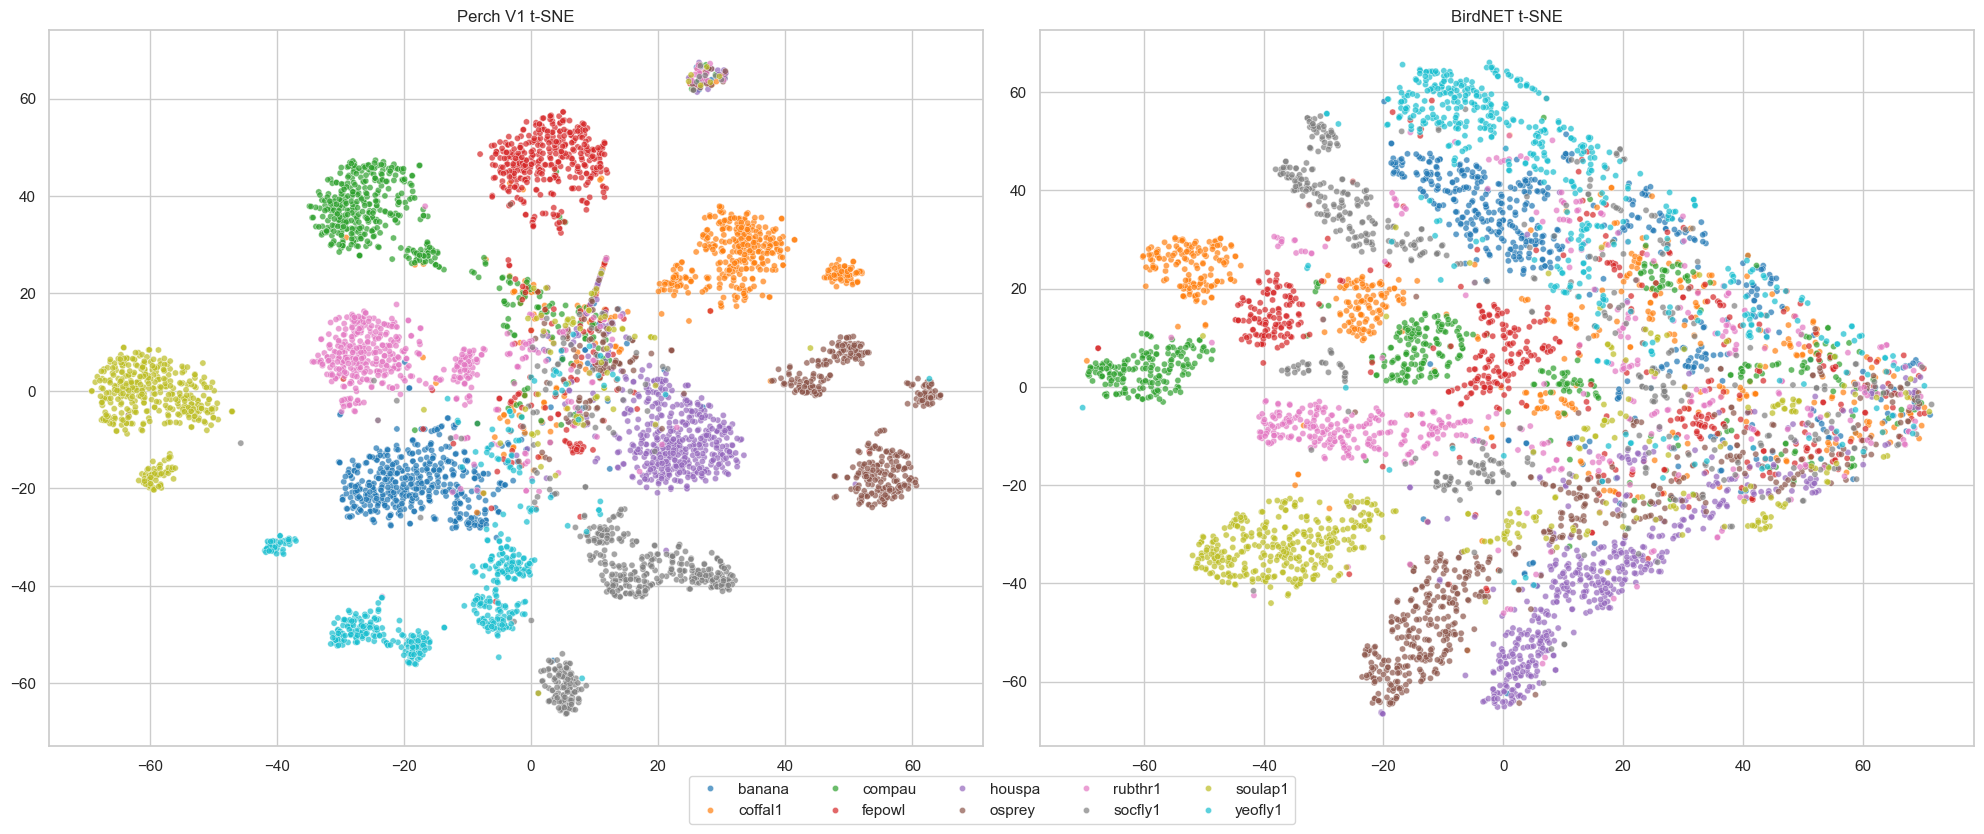

In [4]:
# Get common indices (if any differences exist in processing)
common_indices = np.intersect1d(perch_indices, birdnet_indices)
print(f"Common samples: {len(common_indices)}")

# Filter for top 10 most frequent species in the common subset
subset_labels = train_df.iloc[common_indices]['primary_label']
top_10_species = subset_labels.value_counts().head(10).index.tolist()

mask = subset_labels.isin(top_10_species)
viz_indices = common_indices[mask]
viz_labels = train_df.iloc[viz_indices]['primary_label']

# Map global indices to local embedding matrix indices
perch_map = {idx: i for i, idx in enumerate(perch_indices)}
birdnet_map = {idx: i for i, idx in enumerate(birdnet_indices)}

perch_viz_embeddings = perch_embeddings[[perch_map[idx] for idx in viz_indices]]
birdnet_viz_embeddings = birdnet_embeddings[[birdnet_map[idx] for idx in viz_indices]]

def plot_tsne(data, labels, title, ax):
    pca = PCA(n_components=50)
    data_pca = pca.fit_transform(StandardScaler().fit_transform(data))
    
    tsne = TSNE(n_components=2, random_state=42)
    data_tsne = tsne.fit_transform(data_pca)
    
    sns.scatterplot(x=data_tsne[:, 0], y=data_tsne[:, 1], hue=labels, 
                    palette="tab10", s=20, alpha=0.7, ax=ax)
    ax.set_title(title)
    ax.get_legend().remove()

fig, ax = plt.subplots(1, 2, figsize=(20, 8))
plot_tsne(perch_viz_embeddings, viz_labels, "Perch V1 t-SNE", ax[0])
plot_tsne(birdnet_viz_embeddings, viz_labels, "BirdNET t-SNE", ax[1])

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

## 4. Embedding Similarity

Do both models "agree" on which samples are similar?

In [5]:
# Calculate pairwise distances for a subsample to check agreement
from sklearn.metrics import pairwise_distances
from scipy.stats import pearsonr

# Subsample 1000 points
np.random.seed(42)
sample_size = min(1000, len(viz_indices))
sample_idx = np.random.choice(len(viz_indices), sample_size, replace=False)

perch_sample = perch_viz_embeddings[sample_idx]
birdnet_sample = birdnet_viz_embeddings[sample_idx]

# Pairwise distance matrices
perch_dist = pairwise_distances(perch_sample, metric='cosine')
birdnet_dist = pairwise_distances(birdnet_sample, metric='cosine')

# Extract upper triangle to correlate
upper_tri_indices = np.triu_indices_from(perch_dist, k=1)
perch_pw = perch_dist[upper_tri_indices]
birdnet_pw = birdnet_dist[upper_tri_indices]

corr, p_value = pearsonr(perch_pw, birdnet_pw)
print(f"Pearson Correlation between pairwise distances: {corr:.4f} (p-value: {p_value:.4e})")

Pearson Correlation between pairwise distances: 0.3724 (p-value: 0.0000e+00)


In [6]:
# Nearest Neighbor Agreement
def knn_agreement(dist1, dist2, k=10):
    '''Calculate how many of the top K nearest neighbors overlap between the two spaces.'''
    # Argsort distances (exclude self, which is index 0)
    nn1 = np.argsort(dist1, axis=1)[:, 1:k+1]
    nn2 = np.argsort(dist2, axis=1)[:, 1:k+1]
    
    agreements = []
    for i in range(len(nn1)):
        intersect = np.intersect1d(nn1[i], nn2[i])
        agreements.append(len(intersect) / k)
        
    return np.mean(agreements)

print(f"Top-10 NN Agreement: {knn_agreement(perch_dist, birdnet_dist, k=10):.2%}")
print(f"Top-50 NN Agreement: {knn_agreement(perch_dist, birdnet_dist, k=50):.2%}")

Top-10 NN Agreement: 28.28%


Top-50 NN Agreement: 39.38%


## 5. Conclusion

**Summary of Findings:**
1. **Distributions:** The two embeddings follow different numerical distributions, indicating they may benefit from different normalization strategies before being fed into a classifier.
2. **Cluster Separation:** Both embeddings separate some of the distinct bird calls based on the t-SNE components.
3. **Distance Agreement:** A modest correlation and NN agreement suggest they encode similar structural information, but differences between the two topologies indicate they capture orthogonal features, thus they would ideally be very complimentary for model ensembling. Looking at the pairwise variations underscores the utility of multi-modal fusion pipelines combining both architectures.